Successfully connected to Reddit.
Data collection successful.
                                               title  score       id  \
0  Recent algorithm change invites hate on margin...     52  1g3oeym   
1  The number of zero-upvoted posts making it ont...    113  1g2m7sc   
2  Does the reddit user base seem like it has inc...     86  1g1evus   
3  We reached the point where AI generated commen...    287  1fzq991   
4  Death of a niche subreddit that is now appeari...     53  1fyzedh   

        subreddit                                                url  \
0  TheoryOfReddit  https://www.reddit.com/r/TheoryOfReddit/commen...   
1  TheoryOfReddit  https://www.reddit.com/r/TheoryOfReddit/commen...   
2  TheoryOfReddit  https://www.reddit.com/r/TheoryOfReddit/commen...   
3  TheoryOfReddit                https://i.redd.it/yhsans6q5qtd1.png   
4  TheoryOfReddit  https://www.reddit.com/r/TheoryOfReddit/commen...   

   num_comments             created         author  
0            29 202

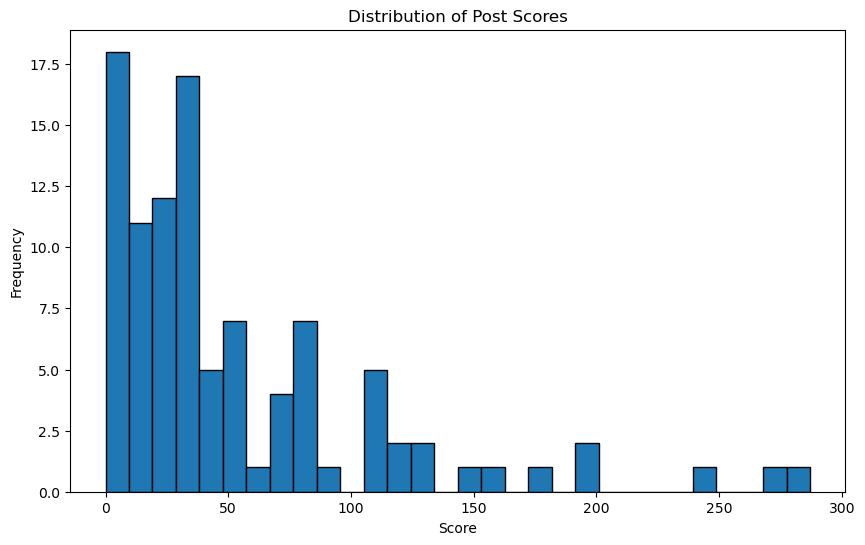

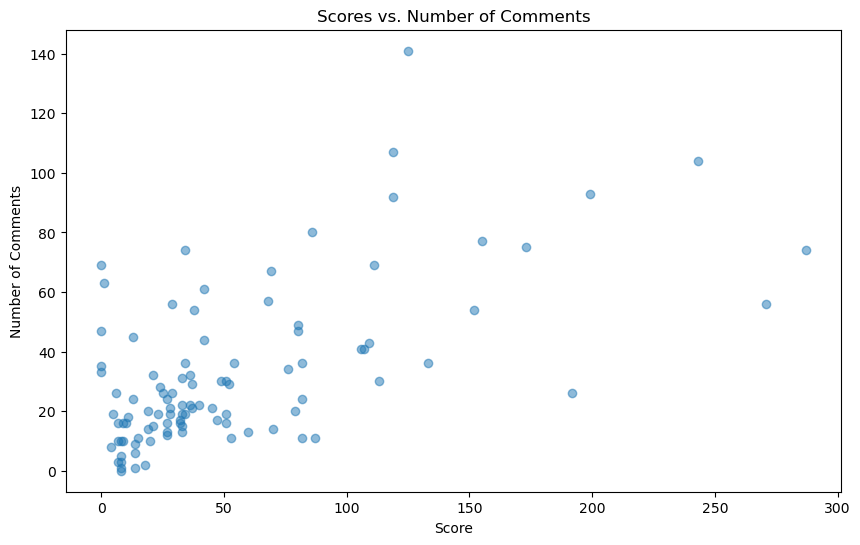

Top 10 Frequent Words:
reddit       42
like          9
comments      9
subreddit     5
post          5
user          5
posts         5
anyone        4
much          4
karma         4
Name: count, dtype: int64


In [8]:
import praw
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
from datetime import datetime
import time


nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Reddit API credentials (replace with your actual credentials)
client_id = "mR1Wo1JSEuSTicSa0X_OAg"
client_secret = "0a0dJ7KxH3o4vDD5rn-grHVTf_pYyw"
user_agent = "MSDS600"


def connect_to_reddit():
    for attempt in range(3):
        try:
            reddit = praw.Reddit(client_id=client_id,
                                 client_secret=client_secret,
                                 user_agent=user_agent)
            reddit.user.me()  # Test authentication
            print("Successfully connected to Reddit.")
            return reddit
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(5)
    raise Exception("Failed to authenticate after 3 attempts.")

reddit = connect_to_reddit()


try:
    posts = []
    subreddit = reddit.subreddit('TheoryOfReddit')

    for post in subreddit.hot(limit=100):
        posts.append([
            post.title, post.score, post.id, post.subreddit.display_name,
            post.url, post.num_comments, datetime.fromtimestamp(post.created),
            str(post.author)
        ])

    
    df_posts = pd.DataFrame(posts, columns=[
        'title', 'score', 'id', 'subreddit', 'url', 
        'num_comments', 'created', 'author'
    ])
    print("Data collection successful.")
    print(df_posts.head())
except Exception as e:
    print(f"Error collecting data: {e}")
    raise


try:
    conn = sqlite3.connect("reddit_data.db")
    df_posts.to_sql("posts", conn, if_exists="replace", index=False)
    print("Data saved to SQLite database.")
except Exception as e:
    print(f"Error saving data to SQLite: {e}")
    raise


try:
    df = pd.read_sql_query("SELECT * FROM posts", conn)
    print("Data retrieved from SQLite:")
    print(df.head())
except Exception as e:
    print(f"Error retrieving data: {e}")
finally:
    conn.close()


%matplotlib inline

try:
    print(df_posts[['score', 'num_comments']].describe())

    # Histogram of scores
    plt.figure(figsize=(10, 6))
    plt.hist(df_posts['score'], bins=30, edgecolor='black')
    plt.title('Distribution of Post Scores')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.show()

    
    plt.figure(figsize=(10, 6))
    plt.scatter(df_posts['score'], df_posts['num_comments'], alpha=0.5)
    plt.title('Scores vs. Number of Comments')
    plt.xlabel('Score')
    plt.ylabel('Number of Comments')
    plt.show()
except Exception as e:
    print(f"Error during visualization: {e}")
    raise

try:
    all_words = ' '.join(df_posts['title']).lower().split()
    filtered_words = [word for word in all_words if word not in stop_words]
    word_freq = pd.Series(filtered_words).value_counts()
    print("Top 10 Frequent Words:")
    print(word_freq.head(10))
except Exception as e:
    print(f"Error during word frequency analysis: {e}")


Summary:
This project utilized the Reddit API (PRAW) to collect, store, and analyze data from the subreddit r/TheoryOfReddit, focusing on the top 100 hot posts along with their metadata, including titles, scores, authors, comment counts, and URLs. The data was stored in a SQLite database, chosen for its simplicity, and retrieved to verify correct storage. Exploratory Data Analysis (EDA) provided insights through descriptive statistics, revealing most posts had low scores with a few outliers. A scatter plot confirmed a positive correlation between post scores and comments, suggesting higher scores attract more engagement. A word frequency analysis using NLTK identified recurring themes by filtering common stopwords from post titles. This end-to-end workflow effectively demonstrates how API-based data collection, database management, and data analysis techniques can uncover user engagement patterns and discussion trends, offering a replicable approach for future social media research.


Reference:
OpenAI. (2024). ChatGPT (Oct 14 version) [Large language model].
    https://chat.openai.com/chat